In [ ]:
import torch
import gc

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import DeiTForImageClassification, DeiTConfig, ViTForImageClassification, ViTConfig, SwinForImageClassification, SwinConfig
from sklearn.preprocessing import label_binarize
import copy
import time
import random

<env>/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Set device for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

Device: cuda


In [4]:
# Data paths
train_path = 'path/to/Raabin_Diffusion/train'
test_path = 'path/to/Raabin_Diffusion/test'
validation_path = 'path/to/Raabin_Diffusion/validation'

# Class labels
class_labels = {
    "Basophil": 0,
    "Eosinophil": 1,
    "Lymphocyte": 2,
    "Monocyte": 3,
    "Neutrophil": 4,
}

In [5]:
# Image processing function
def process_image(image):
    """
    Process an image with CLAHE histogram equalization
    
    Parameters:
    - image: Input RGB image
    
    Returns:
    - Processed image tensor
    """
    # CLAHE histogram equalization (applied only to V channel)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(v)
    himg = cv2.merge((h, s, cl))
    processed_img = cv2.cvtColor(himg, cv2.COLOR_HSV2RGB)

    # Resize and normalize
    resized = cv2.resize(processed_img, (384, 384), interpolation=cv2.INTER_AREA)
    normalized = resized / 255.0
    
    return normalized

In [6]:
class FilePathDataset(Dataset):
    def __init__(self, data_path):
        self.file_paths = []
        self.labels = []
        
        # Walk through data directories and collect file paths and labels
        for folder_name in os.listdir(data_path):
            folder_path = os.path.join(data_path, folder_name)
            if os.path.isdir(folder_path):
                # Check class label
                label = class_labels.get(folder_name)
                if label is not None:
                    # Collect all jpg files in this folder
                    for file_name in os.listdir(folder_path):
                        if file_name.endswith(".jpg"):
                            file_path = os.path.join(folder_path, file_name)
                            self.file_paths.append(file_path)
                            self.labels.append(label)
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        label = self.labels[idx]
        
        # Load image
        try:
            image = cv2.imread(img_path)
            if image is None:
                raise ValueError(f"Image could not be loaded: {img_path}")
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Use process_image function
            processed_img = process_image(image)
            
            # Convert to tensor
            processed_img = torch.tensor(processed_img, dtype=torch.float32).permute(2, 0, 1)  # (3, 384, 384)
            return processed_img, torch.tensor(label, dtype=torch.long)
            
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a dummy image in case of error
            dummy_img = torch.zeros((3, 384, 384), dtype=torch.float32)
            return dummy_img, torch.tensor(label, dtype=torch.long)

In [7]:
# Create DataLoaders with optimized settings
def create_data_loaders(batch_size=32, num_workers=0):
    """
    Create memory-efficient data loaders
    
    Parameters:
    - batch_size: Batch size for training
    - num_workers: Number of workers for parallel data loading
    """
    train_dataset = FilePathDataset(train_path)
    val_dataset = FilePathDataset(validation_path)
    test_dataset = FilePathDataset(test_path)
    
    print(f"Training dataset: {len(train_dataset)} samples")
    print(f"Validation dataset: {len(val_dataset)} samples")
    print(f"Test dataset: {len(test_dataset)} samples")
    
    # Check class distribution
    train_labels = np.array(train_dataset.labels)
    val_labels = np.array(val_dataset.labels)
    test_labels = np.array(test_dataset.labels)
    
    print("\nTraining data class distribution:")
    print(pd.Series(train_labels).value_counts().sort_index())
    
    print("\nValidation data class distribution:")
    print(pd.Series(val_labels).value_counts().sort_index())
    
    print("\nTest data class distribution:")
    print(pd.Series(test_labels).value_counts().sort_index())
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True  # For faster memory transfer with GPU
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, val_loader, test_loader, test_dataset

In [8]:
# Custom model class with Batch Normalization for DeiT
class EnhancedDeiTModel(nn.Module):
    def __init__(self, pretrained_model, num_classes=5):
        super(EnhancedDeiTModel, self).__init__()
        self.backbone = pretrained_model
        
        # Add batch normalization to stabilize training
        self.batch_norm = nn.BatchNorm1d(self.backbone.config.hidden_size)
        
        # Replace the classification head
        self.classifier = nn.Sequential(
            nn.Linear(self.backbone.config.hidden_size, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
        # Initialize the classifier weights
        for module in self.classifier.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
        # Extract features from the backbone
        outputs = self.backbone(x, output_hidden_states=True)
        
        # Get the [CLS] token representation
        cls_token = outputs.hidden_states[-1][:, 0]
        
        # Apply batch normalization
        normalized = self.batch_norm(cls_token)
        
        # Forward through classifier
        logits = self.classifier(normalized)
        
        return logits

In [9]:
# Custom model class with Batch Normalization for ViT
class EnhancedViTModel(nn.Module):
    def __init__(self, pretrained_model, num_classes=5):
        super(EnhancedViTModel, self).__init__()
        self.backbone = pretrained_model
        
        # Add batch normalization to stabilize training
        self.batch_norm = nn.BatchNorm1d(self.backbone.config.hidden_size)
        
        # Replace the classification head
        self.classifier = nn.Sequential(
            nn.Linear(self.backbone.config.hidden_size, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
        # Initialize the classifier weights
        for module in self.classifier.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
        # Extract features from the backbone
        outputs = self.backbone(x, output_hidden_states=True)
        
        # Get the [CLS] token representation
        cls_token = outputs.hidden_states[-1][:, 0]
        
        # Apply batch normalization
        normalized = self.batch_norm(cls_token)
        
        # Forward through classifier
        logits = self.classifier(normalized)
        
        return logits

In [10]:
# Custom model class with Batch Normalization for Swin Transformer
class EnhancedSwinModel(nn.Module):
    def __init__(self, pretrained_model, num_classes=5):
        super(EnhancedSwinModel, self).__init__()
        self.backbone = pretrained_model
        
        # Add batch normalization to stabilize training
        self.batch_norm = nn.BatchNorm1d(self.backbone.config.hidden_size)
        
        # Replace the classification head with a more complex one
        self.classifier = nn.Sequential(
            nn.Linear(self.backbone.config.hidden_size, 768),
            nn.BatchNorm1d(768),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(768, num_classes)

        )
        
        # Initialize the classifier weights
        for module in self.classifier.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
            # Extract features from the backbone
            outputs = self.backbone(x, output_hidden_states=True)
            
            # Get the correct output for Swin
            last_hidden_state = outputs.hidden_states[-1]
            # Apply global average pooling
            pooled_output = torch.mean(last_hidden_state, dim=1)
            
            # Apply batch normalization
            normalized = self.batch_norm(pooled_output)
            
            # Forward through classifier
            logits = self.classifier(normalized)
            
            return logits

In [11]:
# Create class-weighted loss function
def get_weighted_loss():
    # Class counts from training set
    counts = np.array([700, 700, 700, 700, 700])
    weights = 1.0 / (counts / np.sum(counts))
    class_weights = torch.FloatTensor(weights).to(device)
    return nn.CrossEntropyLoss(weight=class_weights)

In [12]:
# Create ensemble models
def create_ensemble_models():
    # DeiT model
    deit_config = DeiTConfig.from_pretrained('facebook/deit-base-distilled-patch16-384', num_labels=5)
    deit_base = DeiTForImageClassification.from_pretrained(
        'facebook/deit-base-distilled-patch16-384', 
        config=deit_config,
        ignore_mismatched_sizes=True
    )
    deit_model = EnhancedDeiTModel(deit_base)
    
    # ViT model
    vit_config = ViTConfig.from_pretrained('google/vit-base-patch16-384', num_labels=5)
    vit_base = ViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-384', 
        config=vit_config,
        ignore_mismatched_sizes=True
    )
    vit_model = EnhancedViTModel(vit_base)

    # Swin Transformer model
    swin_config = SwinConfig.from_pretrained('microsoft/swin-base-patch4-window12-384', num_labels=5)
    swin_base = SwinForImageClassification.from_pretrained(
        'microsoft/swin-base-patch4-window12-384', 
        config=swin_config,
        ignore_mismatched_sizes=True
    )
    swin_model = EnhancedSwinModel(swin_base)
    
    return [deit_model.to(device), vit_model.to(device), swin_model.to(device)]

In [13]:
# Model evaluation function
def evaluate_model(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            
            # Handle Hugging Face model outputs
            if hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs
                
            loss = criterion(logits, labels)
            running_loss += loss.item()

            _, preds = torch.max(logits, 1)
            correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_loader)
    accuracy = correct_preds / total_preds
    return val_loss, accuracy, all_preds, all_labels

In [14]:
# Print function for trainable parameters
def print_trainable_params(model):
    """Print statistics about trainable parameters"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params:,} / {total_params:,} ({trainable_params/total_params:.2%})")

In [15]:
# Improved progressive unfreezing function
def unfreeze_layers_progressively(model, epoch, total_epochs):
    progress = epoch / total_epochs
    
    # Initial epoch - Only train classifier layers
    if epoch == 0:
        # Freeze all parameters
        for param in model.parameters():
            param.requires_grad = False
            
        # Unfreeze only the classifier
        if hasattr(model, 'classifier'):
            for param in model.classifier.parameters():
                param.requires_grad = True
        # For Hugging Face models
        elif hasattr(model, 'classifier') and hasattr(model.classifier, 'parameters'):
            for param in model.classifier.parameters():
                param.requires_grad = True
        # For alternative architectures
        elif hasattr(model, 'head') and hasattr(model.head, 'parameters'):
            for param in model.head.parameters():
                param.requires_grad = True
        
        print_trainable_params(model)
        return
    
    # More gradual unfreezing (4 stages)
    elif progress >= 0.25 and progress < 0.5:
        # Unfreeze last 10% of layers
        backbone_params = []
        if hasattr(model, 'backbone'):
            backbone_params = list(model.backbone.parameters())
        else:
            # If model is directly a backbone
            backbone_params = list(model.parameters())
        
        # Calculate total parameter count
        total_params = len(backbone_params)
        
        # Unfreeze the last 10%
        unfreeze_idx = int(total_params * 0.9)
        for i, param in enumerate(reversed(backbone_params)):
            if i < total_params - unfreeze_idx:
                param.requires_grad = True
    
    elif progress >= 0.5 and progress < 0.75:
        # Unfreeze last 25% of layers
        backbone_params = []
        if hasattr(model, 'backbone'):
            backbone_params = list(model.backbone.parameters())
        else:
            backbone_params = list(model.parameters())
        
        total_params = len(backbone_params)
        
        # Unfreeze the last 25%
        unfreeze_idx = int(total_params * 0.75)
        for i, param in enumerate(reversed(backbone_params)):
            if i < total_params - unfreeze_idx:
                param.requires_grad = True
    
    elif progress >= 0.75:
        # Unfreeze last 50% of layers
        backbone_params = []
        if hasattr(model, 'backbone'):
            backbone_params = list(model.backbone.parameters())
        else:
            backbone_params = list(model.parameters())
        
        total_params = len(backbone_params)
        
        # Unfreeze the last 50%
        unfreeze_idx = int(total_params * 0.5)
        for i, param in enumerate(reversed(backbone_params)):
            if i < total_params - unfreeze_idx:
                param.requires_grad = True
                
    print_trainable_params(model)

In [16]:
# Training function with progressive unfreezing
def train_model_with_progressive_unfreezing(model, train_loader, val_loader, epochs, lr, patience, save_path):
    """Training with progressive unfreezing and ReduceLROnPlateau learning rate scheduling"""
    # Freeze all parameters initially
    for param in model.parameters():
        param.requires_grad = False
        
    # Unfreeze classifier
    for param in model.classifier.parameters():
        param.requires_grad = True
    
    # Define optimizer with weight decay
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=lr, 
        weight_decay=0.001  # Reduced from 0.01
    )
    
    # Use ReduceLROnPlateau scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',          # Try to minimize validation loss
        factor=0.5,          # Multiply learning rate by 0.2 when reducing
        patience=2,          # Wait 3 epochs before reducing
        min_lr=lr/2000       # Minimum learning rate
    )
    
    criterion = get_weighted_loss()

    best_val_loss = float('inf')
    best_val_accuracy = 0.0
    epochs_without_improvement = 0

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    learning_rates = []

    for epoch in range(epochs):
        start_time = time.time()
        
        # Apply progressive unfreezing
        unfreeze_layers_progressively(model, epoch, epochs)

        if epoch == 0:
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=2,
            min_lr=lr/2000
            )
        
        # Update optimizer to include newly unfrozen parameters
        if epoch > 0:
            # Get current learning rate
            last_lr = optimizer.param_groups[0]['lr']
            
            # Update optimizer
            optimizer = optim.AdamW(
                filter(lambda p: p.requires_grad, model.parameters()), 
                lr=last_lr,  # Use current learning rate
                weight_decay=0.001
            )
            
            scheduler.optimizer = optimizer
        
        model.train()
        running_loss = 0.0
        correct_preds = 0
        total_preds = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            
            # Handle Hugging Face model outputs
            if hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs
                
            loss = criterion(logits, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(logits, 1)
            correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = correct_preds / total_preds
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        # Validation
        val_loss, val_accuracy, _, _ = evaluate_model(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        
        # Step scheduler based on validation loss
        scheduler.step(val_loss)

        # Save current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(current_lr)

        end_time = time.time()
        epoch_duration = end_time - start_time
        estimated_remaining_time = epoch_duration * (epochs - epoch - 1)
        estimated_remaining_minutes = estimated_remaining_time / 60

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {epoch_loss:.4f}, Train accuracy: {epoch_accuracy:.4f}")
        print(f"Validation Loss: {val_loss:.4f}, Validation accuracy: {val_accuracy:.4f}")
        print(f"Epoch {epoch+1} completed in {epoch_duration:.2f} seconds")
        print(f"Estimated time remaining: {estimated_remaining_minutes:.2f} minutes")
        print(f"Epoch {epoch+1}, Learning Rate: {current_lr:.8f}")

        # Save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), save_path)
            print(f"Model improved, saved to {save_path}!")
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Early stopping
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
                
        print("Performing memory cleanup...")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print(f"Memory cleaned after epoch {epoch+1}")

    return train_losses, val_losses, train_accuracies, val_accuracies, learning_rates

In [17]:
# Calculate weights for ensemble models based on validation performance
def calculate_ensemble_weights(models, val_loader):
    individual_accuracies = []
    criterion = get_weighted_loss()
    
    for model in models:
        _, val_accuracy, _, _ = evaluate_model(model, val_loader, criterion)
        individual_accuracies.append(val_accuracy)
    
    # Normalize accuracies to get weights
    total_accuracy = sum(individual_accuracies)
    weights = [acc/total_accuracy for acc in individual_accuracies]
    
    print("Ensemble model weights based on validation accuracy:")
    for i, weight in enumerate(weights):
        print(f"Model {i+1}: {weight:.4f}")
        
    return weights

In [18]:
# Ensemble prediction function
def ensemble_predict(models, test_loader, weights=None):
    # Normalize weights
    if weights is None:
        weights = np.ones(len(models)) / len(models)
    else:
        weights = np.array(weights) / np.sum(weights)
    
    all_probabilities = []
    all_labels = []
    
    # For each example, get predictions from each model
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            batch_probs = np.zeros((inputs.size(0), len(class_labels)))
            
            # Add weighted contribution from each model
            for i, model in enumerate(models):
                model.eval()
                outputs = model(inputs)
                
                if hasattr(outputs, 'logits'):
                    logits = outputs.logits
                else:
                    logits = outputs
                
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                batch_probs += weights[i] * probs
            
            all_probabilities.append(batch_probs)
            all_labels.extend(labels.cpu().numpy())
    
    # Combine and get predictions
    all_probabilities = np.vstack(all_probabilities)
    predictions = np.argmax(all_probabilities, axis=1)
    
    return predictions, all_probabilities, np.array(all_labels)

In [19]:
# Test ensemble model
def test_ensemble(models, test_loader, test_dataset, model_weights=None):
    # Get ensemble predictions with model weighting
    test_labels = np.array(test_dataset.labels)
    predictions, probabilities, _ = ensemble_predict(models, test_loader, weights=model_weights)
    
    # Calculate accuracy
    accuracy = np.mean(predictions == test_labels)
    print(f"Ensemble Test Accuracy: {accuracy:.4f}")
    
    # Create confusion matrix
    cm = confusion_matrix(test_labels, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=list(class_labels.keys()), 
                yticklabels=list(class_labels.keys()))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Ensemble Model Confusion Matrix')
    plt.savefig('ensemble_confusion_matrix.png', dpi=300)
    plt.show()
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(test_labels, predictions, 
                               target_names=list(class_labels.keys()), 
                               digits=4))
    
    # ROC curve
    plt.figure(figsize=(10, 8))
    test_labels_bin = label_binarize(test_labels, classes=list(range(len(class_labels))))
    
    for i in range(len(class_labels)):
        fpr, tpr, _ = roc_curve(test_labels_bin[:, i], probabilities[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{list(class_labels.keys())[i]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Ensemble Model ROC Curve')
    plt.legend(loc="lower right")
    plt.savefig('ensemble_roc_curve.png', dpi=300)
    plt.show()
    
    return accuracy, predictions, probabilities

Training dataset: 3500 samples
Validation dataset: 500 samples
Test dataset: 250 samples

Training data class distribution:
0    700
1    700
2    700
3    700
4    700
Name: count, dtype: int64

Validation data class distribution:
0    100
1    100
2    100
3    100
4    100
Name: count, dtype: int64

Test data class distribution:
0    50
1    50
2    50
3    50
4    50
Name: count, dtype: int64


[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3149.66it/s]
[transformers] DeiTForImageClassification LOAD REPORT from: facebook/deit-base-distilled-patch16-384
Key                            | Status     | 
-------------------------------+------------+-
distillation_classifier.bias   | UNEXPECTED | 
cls_classifier.weight          | UNEXPECTED | 
distillation_classifier.weight | UNEXPECTED | 
cls_classifier.bias            | UNEXPECTED | 
classifier.bias                | MISSING    | 
classifier.weight              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.



Training DeiT model...
Trainable parameters: 397,317 / 86,494,730 (0.46%)
Epoch 1/30
Training Loss: 9.0004, Train accuracy: 0.4029
Validation Loss: 2.1951, Validation accuracy: 0.6740
Epoch 1 completed in 46.28 seconds
Estimated time remaining: 22.37 minutes
Epoch 1, Learning Rate: 0.00005000
Model improved, saved to DeiT_best_model.pth!
Performing memory cleanup...
Memory cleaned after epoch 1
Trainable parameters: 397,317 / 86,494,730 (0.46%)
Epoch 2/30
Training Loss: 4.7241, Train accuracy: 0.5951
Validation Loss: 1.1399, Validation accuracy: 0.8220
Epoch 2 completed in 44.23 seconds
Estimated time remaining: 20.64 minutes
Epoch 2, Learning Rate: 0.00005000
Model improved, saved to DeiT_best_model.pth!
Performing memory cleanup...
Memory cleaned after epoch 2
Trainable parameters: 397,317 / 86,494,730 (0.46%)
Epoch 3/30
Training Loss: 3.2368, Train accuracy: 0.7003
Validation Loss: 0.8883, Validation accuracy: 0.8560
Epoch 3 completed in 43.96 seconds
Estimated time remaining: 19.7

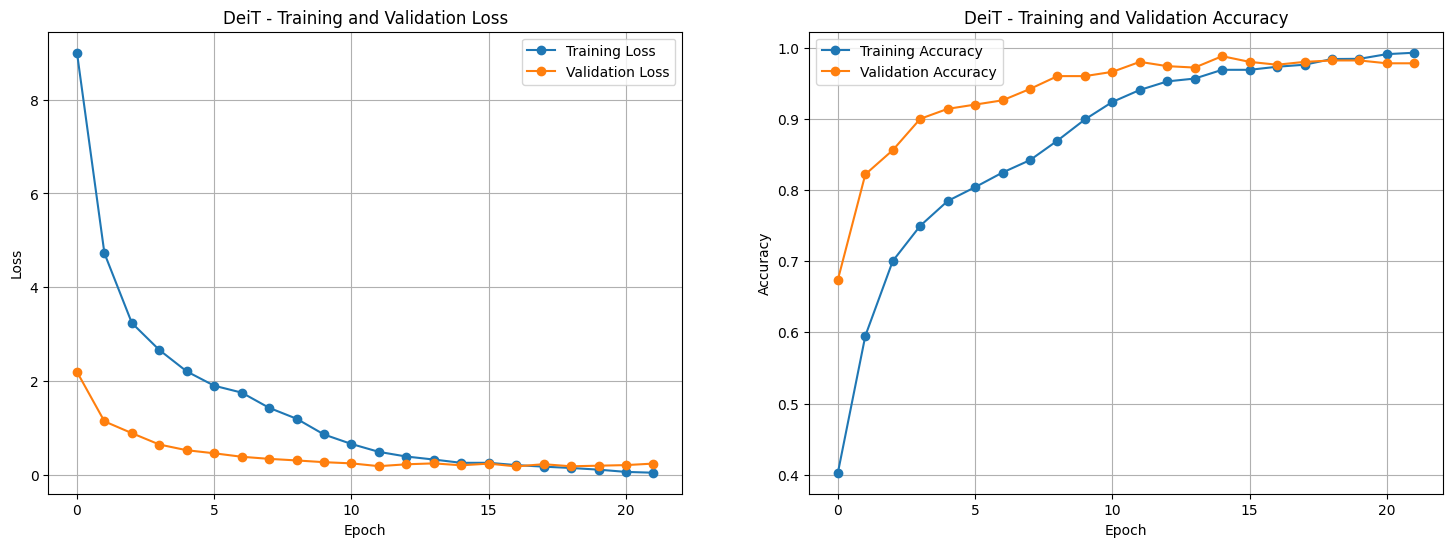

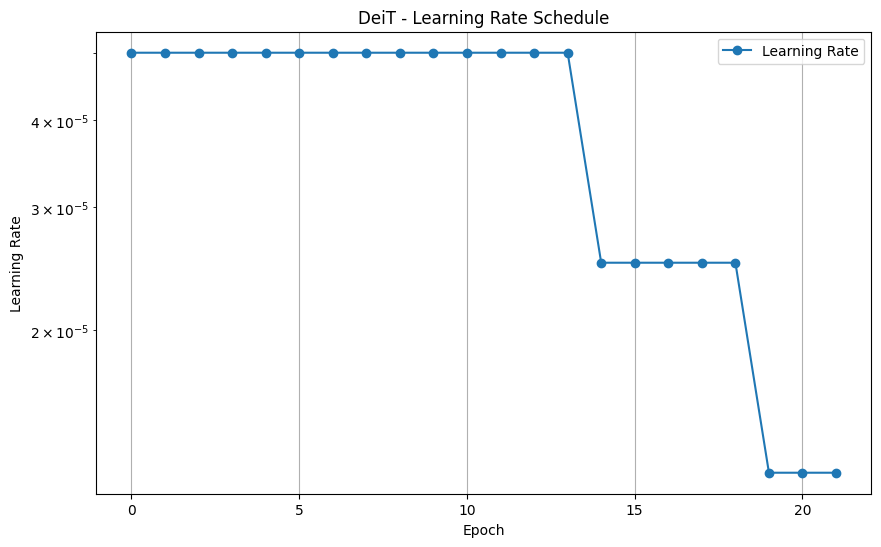

Loading best model weights from DeiT_best_model.pth
Cleaning up memory after training DeiT...
Memory cleanup completed for DeiT

Training ViT model...
Trainable parameters: 397,317 / 86,493,194 (0.46%)
Epoch 1/30
Training Loss: 6.1631, Train accuracy: 0.5591
Validation Loss: 1.3109, Validation accuracy: 0.8400
Epoch 1 completed in 44.15 seconds
Estimated time remaining: 21.34 minutes
Epoch 1, Learning Rate: 0.00005000
Model improved, saved to ViT_best_model.pth!
Performing memory cleanup...
Memory cleaned after epoch 1
Trainable parameters: 397,317 / 86,493,194 (0.46%)
Epoch 2/30
Training Loss: 2.6017, Train accuracy: 0.7686
Validation Loss: 0.9754, Validation accuracy: 0.8840
Epoch 2 completed in 44.68 seconds
Estimated time remaining: 20.85 minutes
Epoch 2, Learning Rate: 0.00005000
Model improved, saved to ViT_best_model.pth!
Performing memory cleanup...
Memory cleaned after epoch 2
Trainable parameters: 397,317 / 86,493,194 (0.46%)
Epoch 3/30
Training Loss: 1.9992, Train accuracy: 

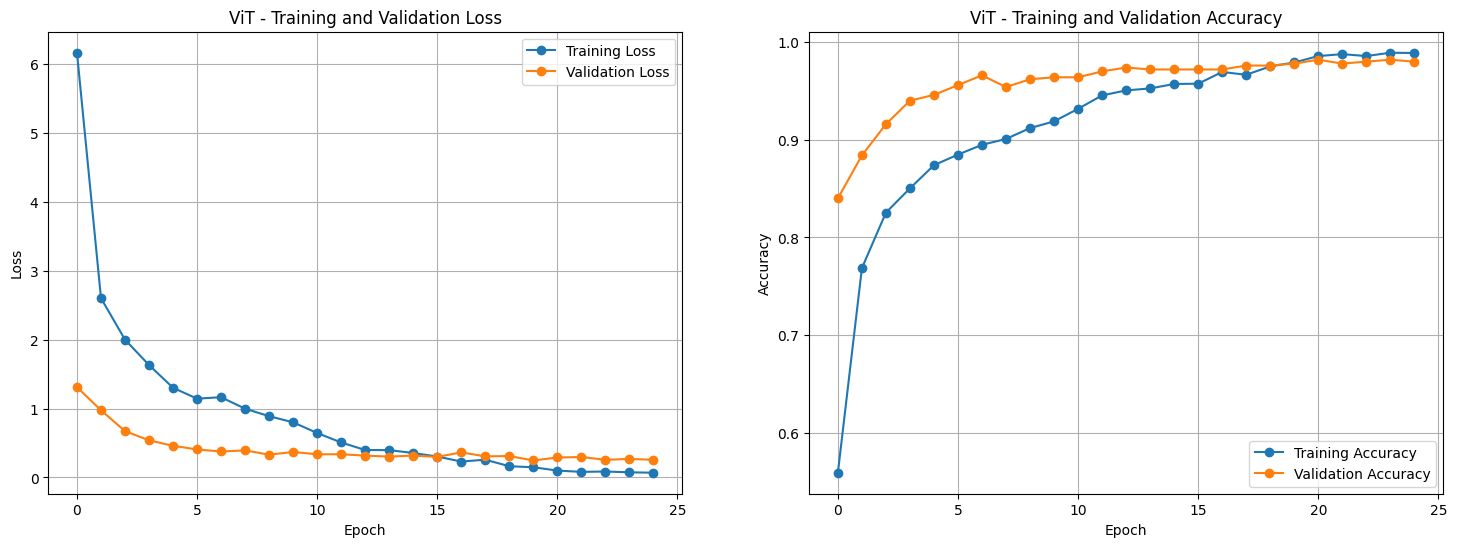

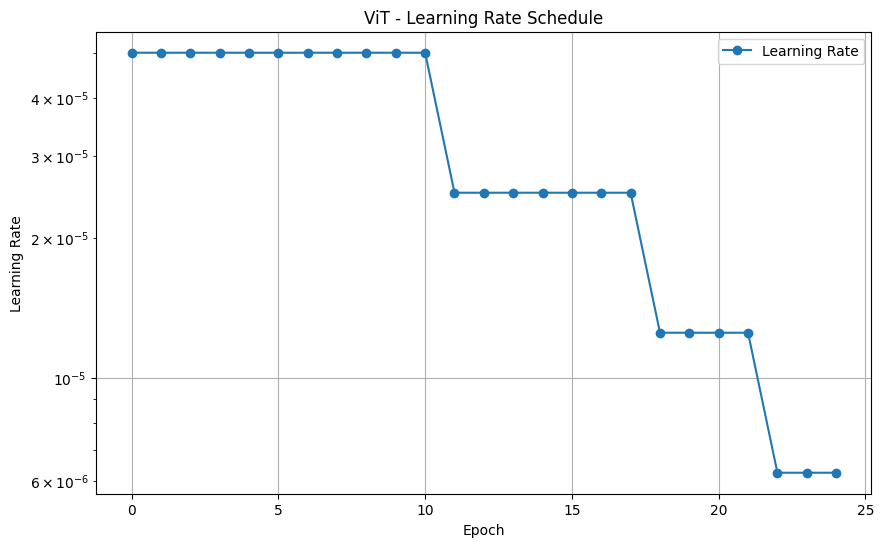

Loading best model weights from ViT_best_model.pth
Cleaning up memory after training ViT...
Memory cleanup completed for ViT

Training Swin model...
Trainable parameters: 792,581 / 87,678,338 (0.90%)
Epoch 1/30
Training Loss: 10.7778, Train accuracy: 0.4154
Validation Loss: 1.5948, Validation accuracy: 0.7840
Epoch 1 completed in 58.04 seconds
Estimated time remaining: 28.05 minutes
Epoch 1, Learning Rate: 0.00005000
Model improved, saved to Swin_best_model.pth!
Performing memory cleanup...
Memory cleaned after epoch 1
Trainable parameters: 792,581 / 87,678,338 (0.90%)
Epoch 2/30
Training Loss: 5.6185, Train accuracy: 0.6160
Validation Loss: 0.9341, Validation accuracy: 0.8580
Epoch 2 completed in 57.93 seconds
Estimated time remaining: 27.03 minutes
Epoch 2, Learning Rate: 0.00005000
Model improved, saved to Swin_best_model.pth!
Performing memory cleanup...
Memory cleaned after epoch 2
Trainable parameters: 792,581 / 87,678,338 (0.90%)
Epoch 3/30
Training Loss: 4.4532, Train accuracy:

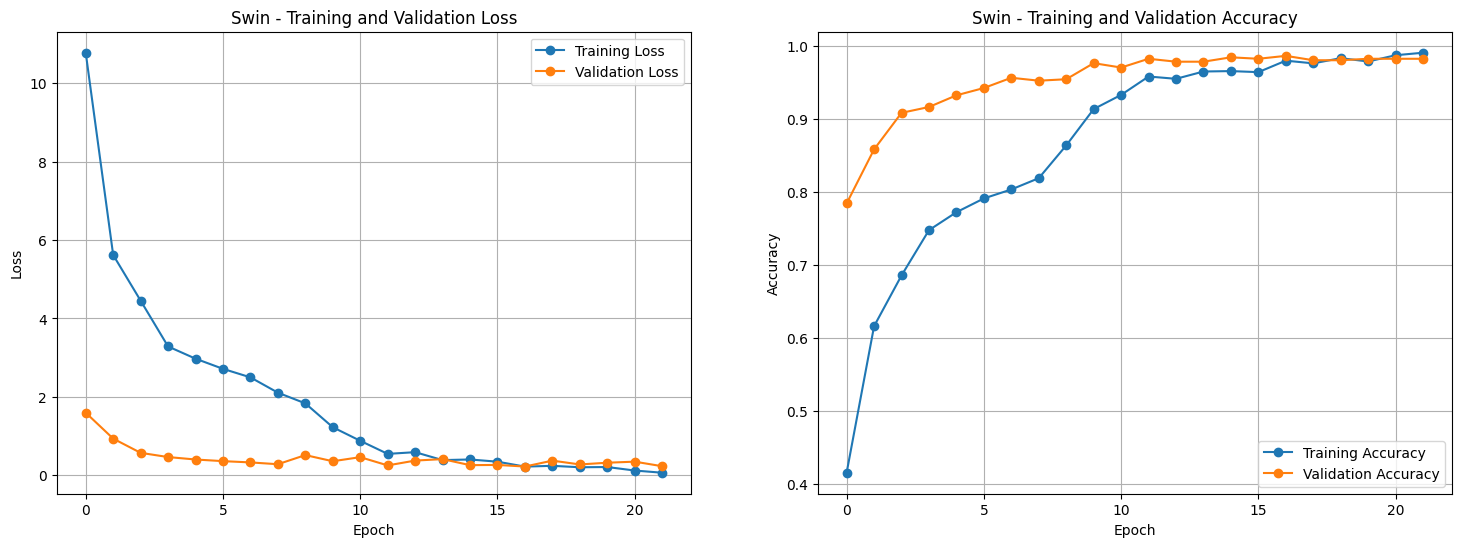

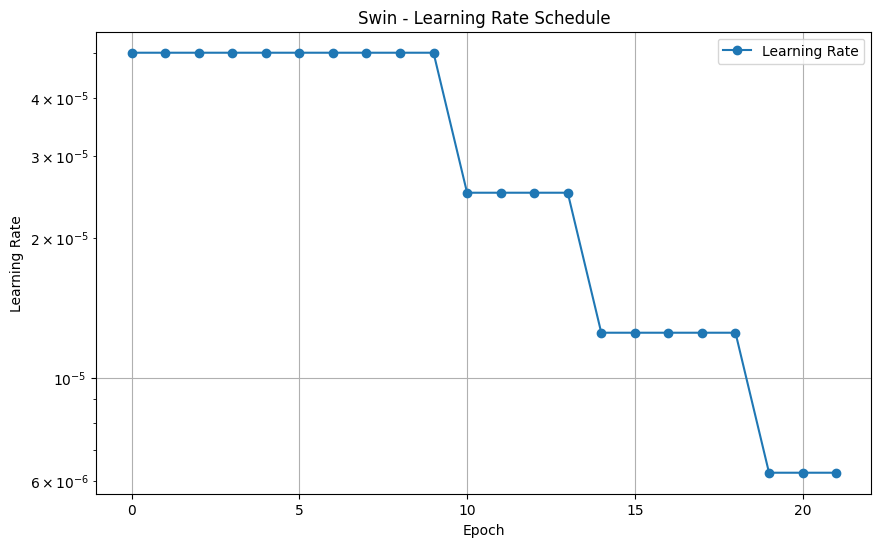

Loading best model weights from Swin_best_model.pth
Cleaning up memory after training Swin...
Memory cleanup completed for Swin
Ensemble model weights based on validation accuracy:
Model 1: 0.3320
Model 2: 0.3327
Model 3: 0.3354

Evaluating ensemble model performance...
Ensemble Test Accuracy: 0.9920


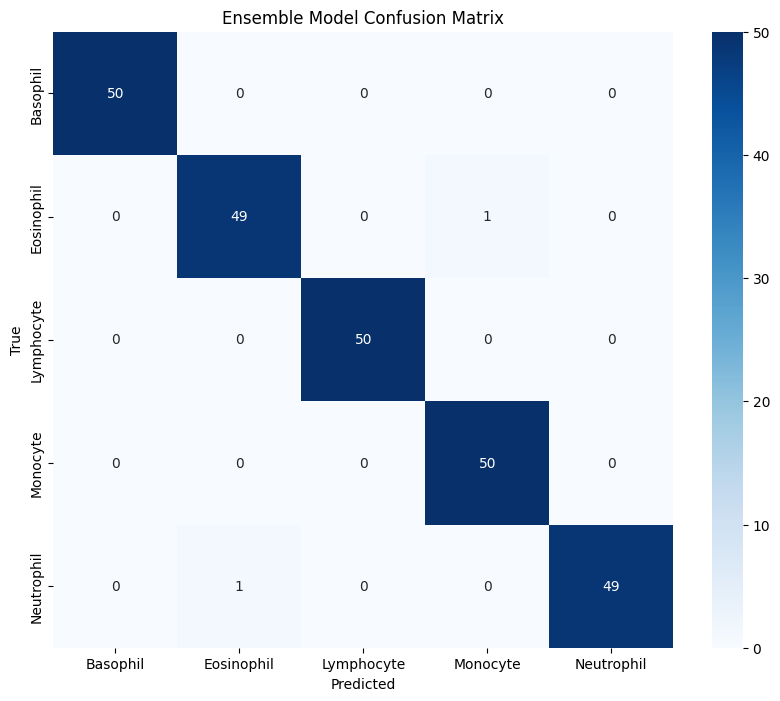


Classification Report:
              precision    recall  f1-score   support

    Basophil     1.0000    1.0000    1.0000        50
  Eosinophil     0.9800    0.9800    0.9800        50
  Lymphocyte     1.0000    1.0000    1.0000        50
    Monocyte     0.9804    1.0000    0.9901        50
  Neutrophil     1.0000    0.9800    0.9899        50

    accuracy                         0.9920       250
   macro avg     0.9921    0.9920    0.9920       250
weighted avg     0.9921    0.9920    0.9920       250



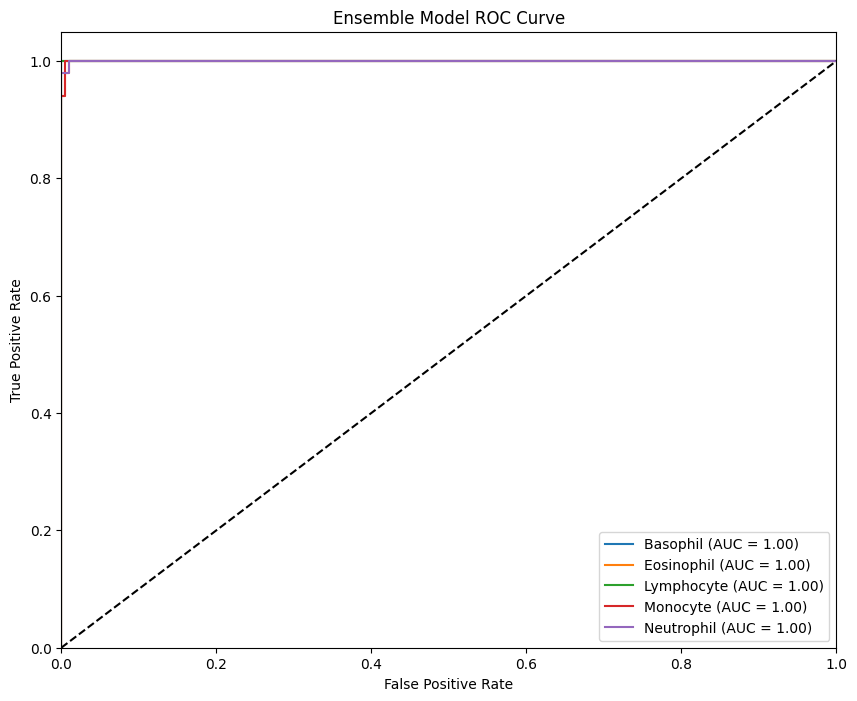


Model Performance Comparison:
--------------------------------------------------
DeiT Test Accuracy: 0.9720
ViT Test Accuracy: 0.9760
Swin Test Accuracy: 0.9840
Ensemble Test Accuracy: 0.9920
Improvement over best individual model: 0.80%
Ensemble model saved successfully!


In [ ]:
def main():
    # Create data loaders
    train_loader, val_loader, test_loader, test_dataset = create_data_loaders(
        batch_size=32,  # Increased batch size
        num_workers=0   # Adjust based on system cores
    )

    # Create ensemble models
    models = create_ensemble_models()
    
    # Training configuration
    config = {
        "epochs": 30,         
        "learning_rate": 5e-5, 
        "patience": 5     
    }
    
    # Train each model in the ensemble
    trained_models = []
    model_names = ["DeiT", "ViT", "Swin"]
    
    for i, model in enumerate(models):
        print(f"\nTraining {model_names[i]} model...")
        
        # Define model save path
        model_save_path = f'{model_names[i]}_best_model.pth'
        
        # Train with progressive unfreezing
        train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model_with_progressive_unfreezing(
            model, 
            train_loader, 
            val_loader, 
            config["epochs"], 
            config["learning_rate"], 
            config["patience"],
            model_save_path
        )
        
        # Plot training metrics
        fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
        
        # Loss plot
        ax1.plot(train_losses, label='Training Loss', marker='o')
        ax1.plot(val_losses, label='Validation Loss', marker='o')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title(f'{model_names[i]} - Training and Validation Loss')
        ax1.legend()
        ax1.grid()
        
        # Accuracy plot
        ax2.plot(train_accuracies, label='Training Accuracy', marker='o')
        ax2.plot(val_accuracies, label='Validation Accuracy', marker='o')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title(f'{model_names[i]} - Training and Validation Accuracy')
        ax2.legend()
        ax2.grid()
        
        plt.savefig(f'{model_names[i]}_training_validation_metrics.png', dpi=300)
        plt.show()
        
        # Learning rate plot
        plt.figure(figsize=(10, 6))
        plt.plot(learning_rates, label='Learning Rate', marker='o')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.title(f'{model_names[i]} - Learning Rate Schedule')
        plt.legend()
        plt.grid()
        plt.yscale('log')
        plt.savefig(f'{model_names[i]}_learning_rate.png', dpi=300)
        plt.show()
        
        # Load the best model weights if the file exists
        if os.path.exists(model_save_path):
            print(f"Loading best model weights from {model_save_path}")
            model.load_state_dict(torch.load(model_save_path))
        else:
            print(f"No saved model found at {model_save_path}, using the current model state")
        
        trained_models.append(model)

        # Memory cleanup after each model
        print(f"Cleaning up memory after training {model_names[i]}...")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print(f"Memory cleanup completed for {model_names[i]}")
        
    
    # Calculate ensemble weights based on validation performance
    model_weights = calculate_ensemble_weights(trained_models, val_loader)
    
    # Test the ensemble model
    print("\nEvaluating ensemble model performance...")
    ensemble_accuracy, ensemble_predictions, ensemble_probabilities = test_ensemble(
        trained_models, 
        test_loader, 
        test_dataset,
        model_weights
    )
    
    # Compare individual model performance with ensemble
    print("\nModel Performance Comparison:")
    print("-" * 50)
    
    individual_accuracies = []
    for i, model in enumerate(trained_models):
        model_name = model_names[i]
        val_loss, val_accuracy, _, _ = evaluate_model(model, test_loader, get_weighted_loss())
        individual_accuracies.append(val_accuracy)
        print(f"{model_name} Test Accuracy: {val_accuracy:.4f}")
    
    print(f"Ensemble Test Accuracy: {ensemble_accuracy:.4f}")
    if individual_accuracies:
        print(f"Improvement over best individual model: {(ensemble_accuracy - max(individual_accuracies)) * 100:.2f}%")
    
    # Save the ensemble model
    ensemble_models = {
        "models": [model.state_dict() for model in trained_models],
        "model_names": model_names,
        "class_labels": class_labels,
        "model_weights": model_weights
    }
    torch.save(ensemble_models, "blood_cell_classification_ensemble.pth")
    print("Ensemble model saved successfully!")

if __name__ == "__main__":
    main()